## 1. Setup and Imports

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, classification_report
)
import joblib
import os

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

RANDOM_STATE = 42
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Dataset and EDA

In [38]:
df = pd.read_csv('./ai_resume_screening.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (30000, 7)


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
0,6,84.7,Bachelors,7,234,158,No
1,3,59.1,Masters,5,502,77,No
2,12,100.0,Masters,12,753,381,Yes
3,14,66.8,High School,8,529,407,Yes
4,10,99.6,Bachelors,10,754,331,Yes


In [39]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
years_experience        int64
skills_match_score    float64
education_level        object
project_count           int64
resume_length           int64
github_activity         int64
shortlisted            object
dtype: object

=== Missing Values ===
years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
dtype: int64


In [40]:
print('=== Descriptive Statistics ===')
df.describe(include='all')

=== Descriptive Statistics ===


,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted
count,30000.000000,30000.000000,30000,30000.000000,30000.000000,30000.000000,30000
unique,NaN,NaN,4,NaN,NaN,NaN,2
top,NaN,NaN,Bachelors,NaN,NaN,NaN,Yes
freq,NaN,NaN,13461,NaN,NaN,NaN,20966
mean,7.506567,73.682653,NaN,10.646267,572.584700,325.260667,NaN
std,4.624104,16.765909,NaN,4.634047,178.709918,159.951803,NaN
min,0.000000,0.500000,NaN,0.000000,150.000000,0.000000,NaN
25%,3.750000,62.100000,NaN,7.000000,441.000000,202.000000,NaN
50%,7.000000,74.300000,NaN,10.000000,574.000000,321.000000,NaN
75%,12.000000,86.500000,NaN,14.000000,709.000000,443.000000,NaN


Graphical EDA

=== Target Distribution ===
             Count  Percentage (%)
shortlisted                       
No            9034           30.11
Yes          20966           69.89


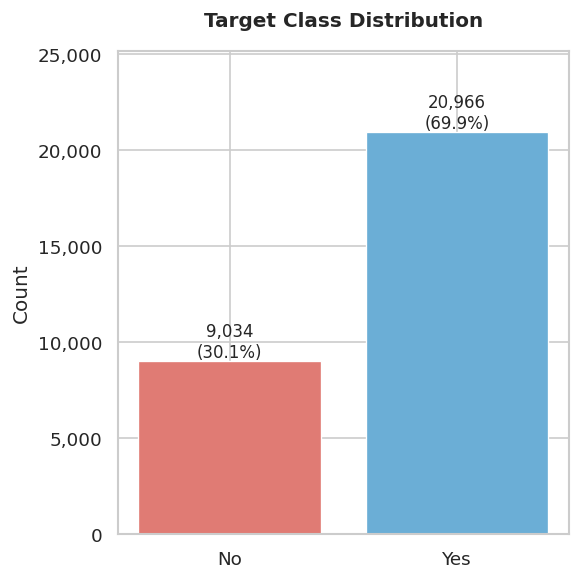

In [41]:
print('=== Target Distribution ===')
counts = df['shortlisted'].value_counts().sort_index()
pcts   = df['shortlisted'].value_counts(normalize=True).sort_index() * 100
print(pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)}))

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(counts.index, counts.values,
       color=['#E07B74', '#6BAED6'], edgecolor='white', linewidth=0.8)
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    ax.text(i, c + 200, f'{c:,}\n({p:.1f}%)', ha='center', fontsize=10)
ax.set_title('Target Class Distribution', fontweight='bold', pad=15)
ax.set_ylabel('Count')
ax.set_ylim(0, counts.max() * 1.20)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

In [42]:
print('=== Categorical Value Counts ===')
print(df['education_level'].value_counts())

=== Categorical Value Counts ===
education_level
Bachelors      13461
Masters        10524
PhD             3024
High School     2991
Name: count, dtype: int64


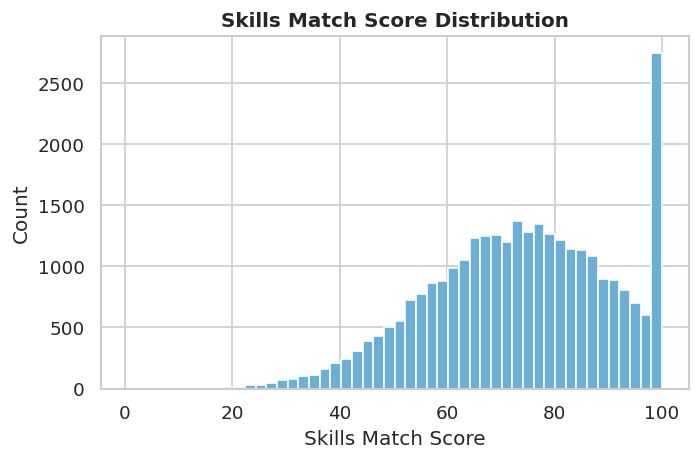

Skills Match Score — min: 0.5, max: 100.0, mean: 73.68


In [43]:
# Skills match score distribution
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['skills_match_score'], bins=50, color='#6BAED6', edgecolor='white')
ax.set_title('Skills Match Score Distribution', fontweight='bold')
ax.set_xlabel('Skills Match Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Skills Match Score — min: {df["skills_match_score"].min()}, max: {df["skills_match_score"].max()}, mean: {df["skills_match_score"].mean():.2f}')

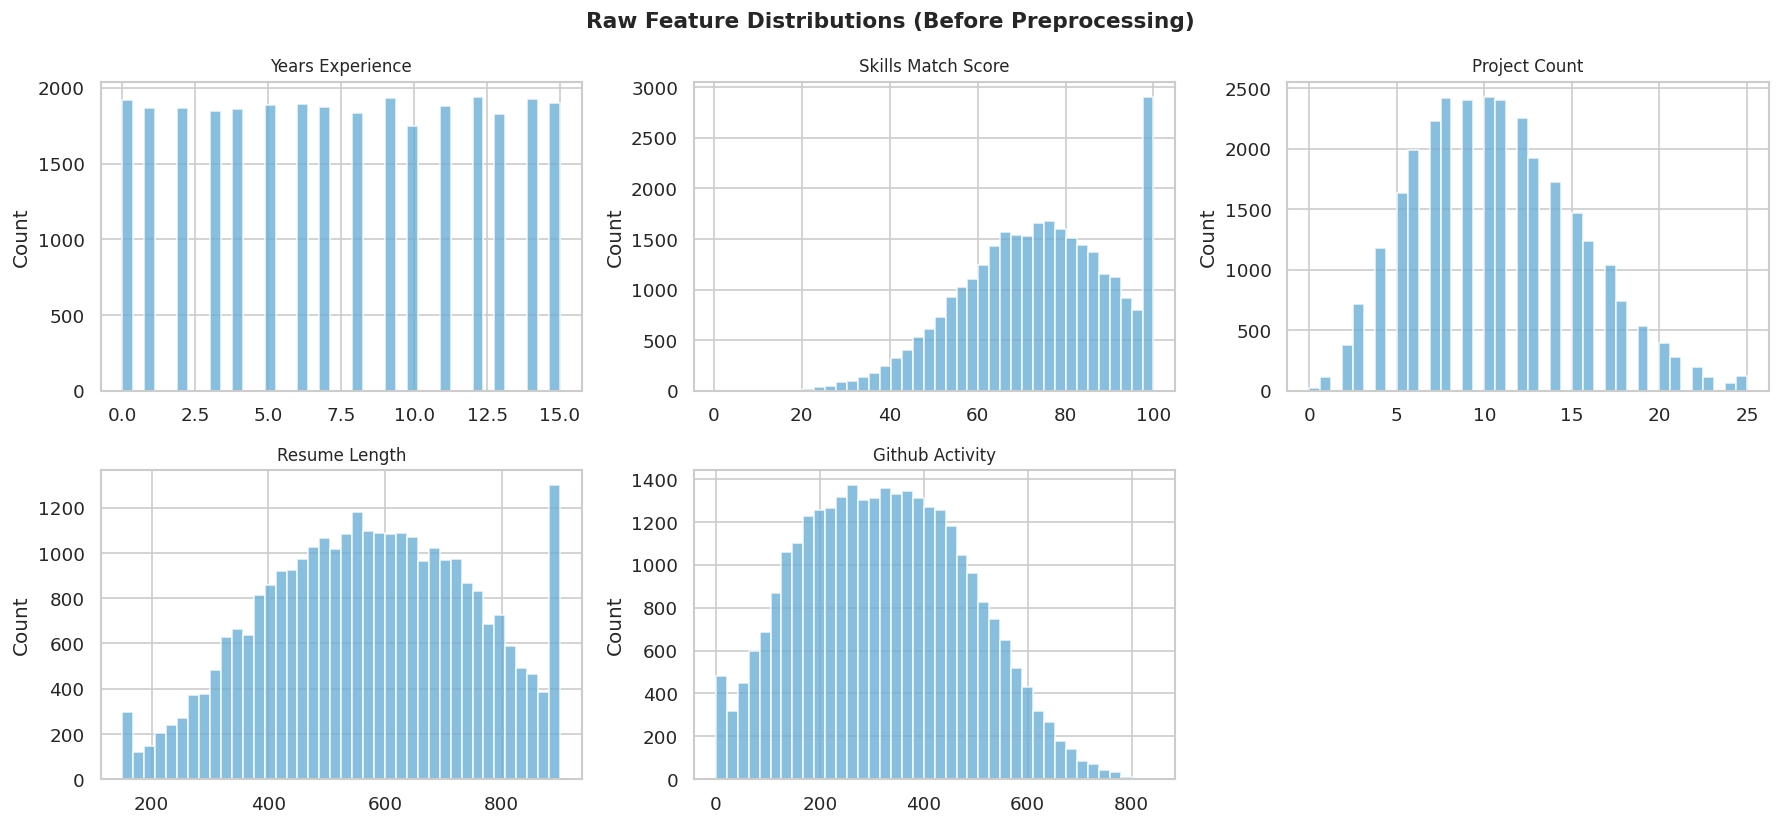

In [44]:
# Raw numerical feature distributions
num_cols_raw = ['years_experience', 'skills_match_score', 'project_count',
                'resume_length', 'github_activity']

n_cols = 3
n_rows = int(np.ceil(len(num_cols_raw) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols_raw):
    axes[i].hist(df[col], bins=40, color='#6BAED6', edgecolor='white', alpha=0.8)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].set_ylabel('Count')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Raw Feature Distributions (Before Preprocessing)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

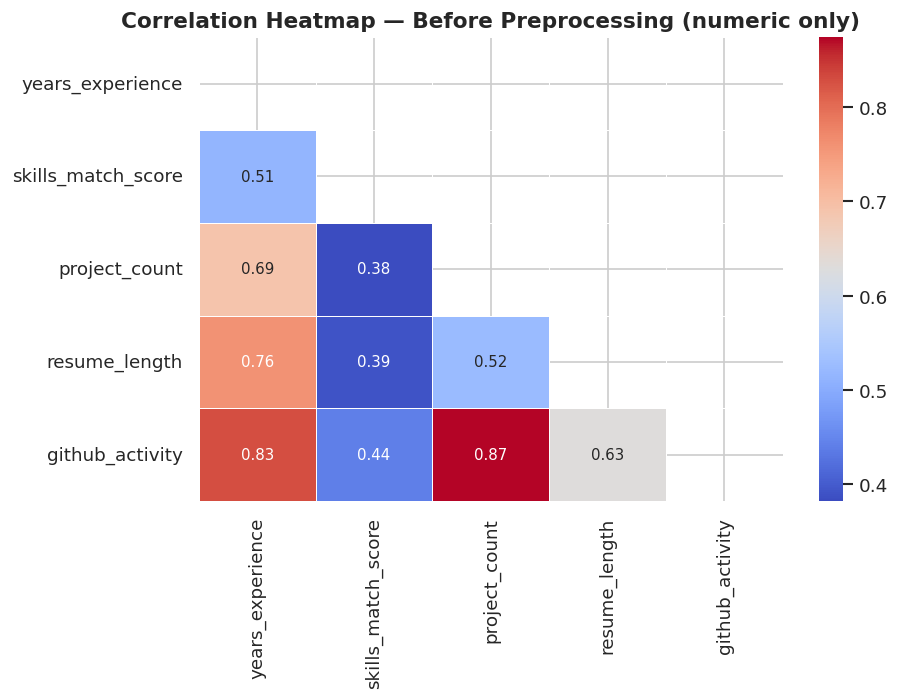

In [45]:
# Correlation heatmap BEFORE preprocessing
fig, ax = plt.subplots(figsize=(8, 6))
corr_raw = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr_raw, dtype=bool))
sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — Before Preprocessing (numeric only)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

=== IQR Outlier Summary ===
years_experience          | Bounds: [-8.62, 24.38] | Outliers: 0 (0.00%)
skills_match_score        | Bounds: [25.50, 123.10] | Outliers: 81 (0.27%)
project_count             | Bounds: [-3.50, 24.50] | Outliers: 118 (0.39%)
resume_length             | Bounds: [39.00, 1111.00] | Outliers: 0 (0.00%)
github_activity           | Bounds: [-159.50, 804.50] | Outliers: 9 (0.03%)


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
Feature,,,,,,,
years_experience,3.75,12.0,8.25,-8.625,24.375,0,0.00
skills_match_score,62.10,86.5,24.40,25.500,123.100,81,0.27
project_count,7.00,14.0,7.00,-3.500,24.500,118,0.39
resume_length,441.00,709.0,268.00,39.000,1111.000,0,0.00
github_activity,202.00,443.0,241.00,-159.500,804.500,9,0.03


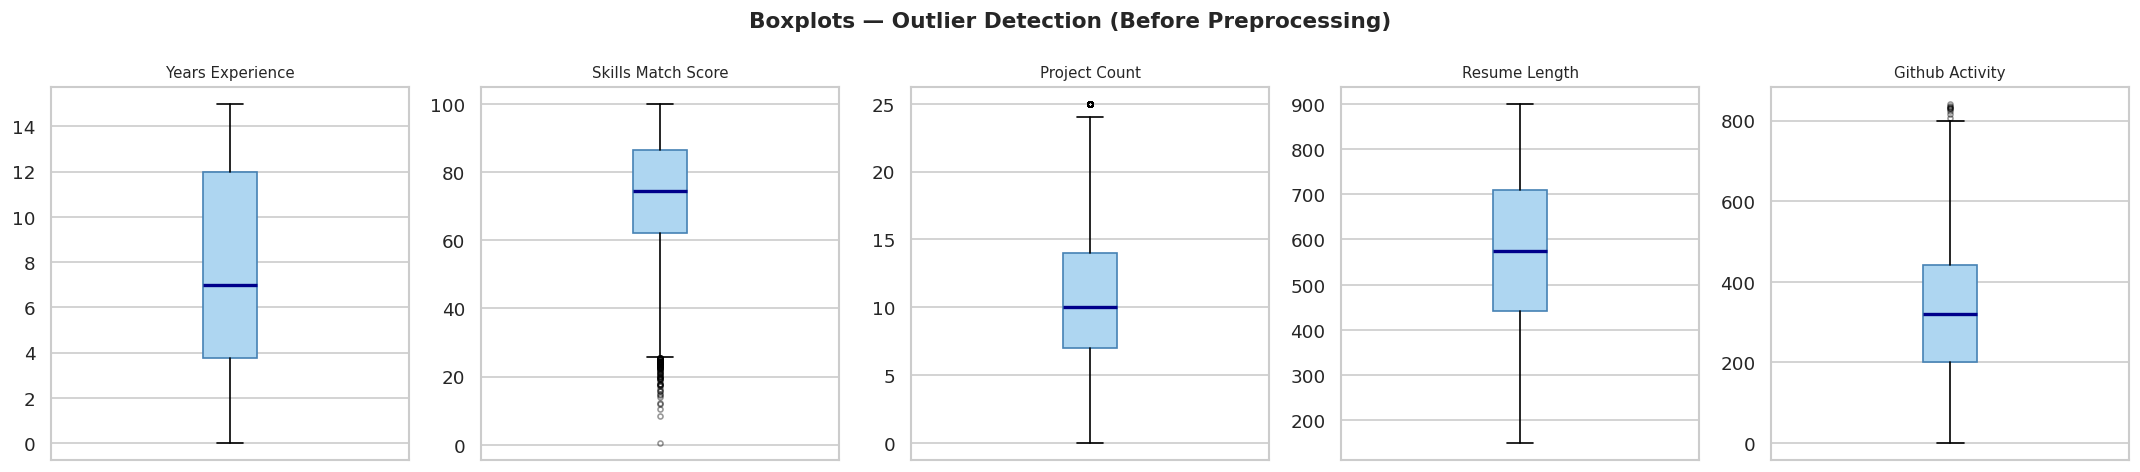

In [46]:
num_cols_check = ['years_experience', 'skills_match_score', 'project_count',
                   'resume_length', 'github_activity']

print('=== IQR Outlier Summary ===')
outlier_summary = []
for col in num_cols_check:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    pct   = n_out / len(df) * 100
    outlier_summary.append({'Feature': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                             'Lower Bound': lower, 'Upper Bound': upper,
                             'Outlier Count': n_out, 'Outlier %': round(pct, 2)})
    print(f'{col:25s} | Bounds: [{lower:.2f}, {upper:.2f}] | Outliers: {n_out} ({pct:.2f}%)')

outlier_df = pd.DataFrame(outlier_summary).set_index('Feature')
display(outlier_df)

# Boxplot visualisation
fig, axes = plt.subplots(1, len(num_cols_check), figsize=(18, 4))
for ax, col in zip(axes, num_cols_check):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#AED6F1', color='steelblue'),
               medianprops=dict(color='darkblue', linewidth=2),
               flierprops=dict(marker='o', color='#E07B74', alpha=0.4, markersize=3))
    ax.set_title(col.replace('_', ' ').title(), fontsize=9)
    ax.set_xticks([])
fig.suptitle('Boxplots — Outlier Detection (Before Preprocessing)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [47]:
# No columns to drop — copy raw df
df_clean = df.copy()
print('Columns:', df_clean.columns.tolist())

# Encode target: Yes -> 1, No -> 0
df_clean['shortlisted'] = (df_clean['shortlisted'] == 'Yes').astype(int)
print('Target encoded: Yes=1, No=0')
print(df_clean['shortlisted'].value_counts())

Columns: ['years_experience', 'skills_match_score', 'education_level', 'project_count', 'resume_length', 'github_activity', 'shortlisted']
Target encoded: Yes=1, No=0
shortlisted
1    20966
0     9034
Name: count, dtype: int64


In [48]:
print('Class distribution:')
print(df_clean['shortlisted'].value_counts())

Class distribution:
shortlisted
1    20966
0     9034
Name: count, dtype: int64


In [49]:
# Ordinal encode education_level (preserves meaningful order)
edu_order = ['High School', 'Bachelors', 'Masters', 'PhD']
oe = OrdinalEncoder(categories=[edu_order], handle_unknown='use_encoded_value', unknown_value=-1)
df_clean['education_level'] = oe.fit_transform(df_clean[['education_level']]).astype(int)
print('Education level ordinal mapping:')
for i, lvl in enumerate(edu_order):
    print(f'  {lvl} -> {i}')

# Feature Engineering
df_clean['exp_x_skills']   = df_clean['years_experience'] * df_clean['skills_match_score']
df_clean['resume_per_proj']= df_clean['resume_length'] / (df_clean['project_count'] + 1)
print('Engineered features: exp_x_skills, resume_per_proj')
print('Columns:', df_clean.columns.tolist())

Education level ordinal mapping:
  High School -> 0
  Bachelors -> 1
  Masters -> 2
  PhD -> 3
Engineered features: exp_x_skills, resume_per_proj
Columns: ['years_experience', 'skills_match_score', 'education_level', 'project_count', 'resume_length', 'github_activity', 'shortlisted', 'exp_x_skills', 'resume_per_proj']


In [50]:
print('Missing values after preprocessing:')
print(df_clean.isnull().sum())
print()
df_clean.head()

Missing values after preprocessing:
years_experience      0
skills_match_score    0
education_level       0
project_count         0
resume_length         0
github_activity       0
shortlisted           0
exp_x_skills          0
resume_per_proj       0
dtype: int64



,years_experience,skills_match_score,education_level,project_count,resume_length,github_activity,shortlisted,exp_x_skills,resume_per_proj
0,6,84.7,1,7,234,158,0,508.2,29.250000
1,3,59.1,2,5,502,77,0,177.3,83.666667
2,12,100.0,2,12,753,381,1,1200.0,57.923077
3,14,66.8,0,8,529,407,1,935.2,58.777778
4,10,99.6,1,10,754,331,1,996.0,68.545455


## 4. EDA After Preprocessing

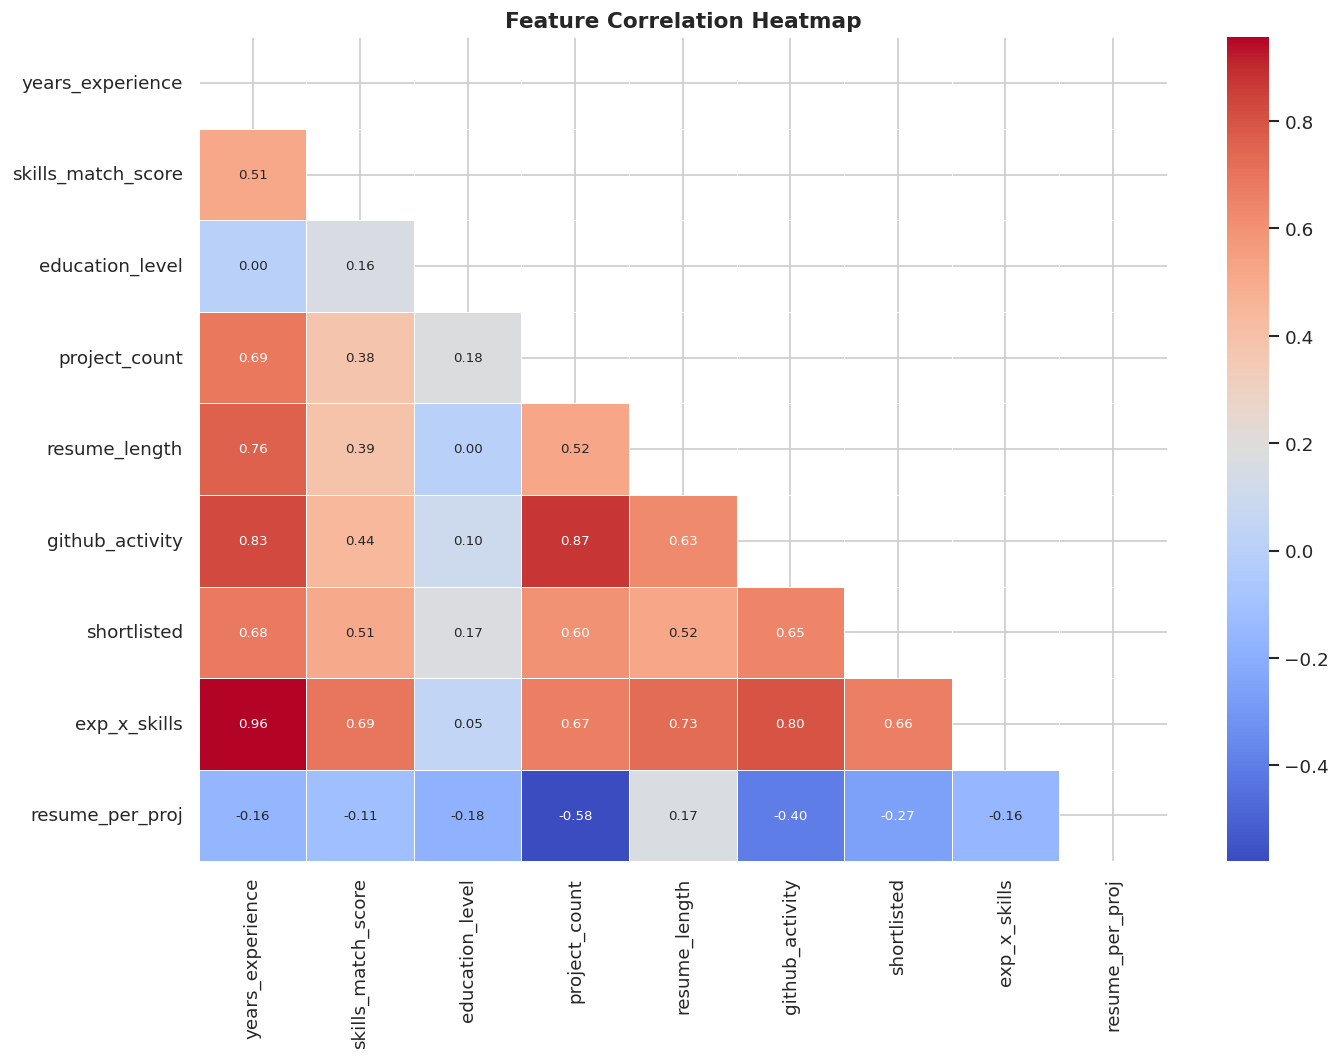

In [51]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

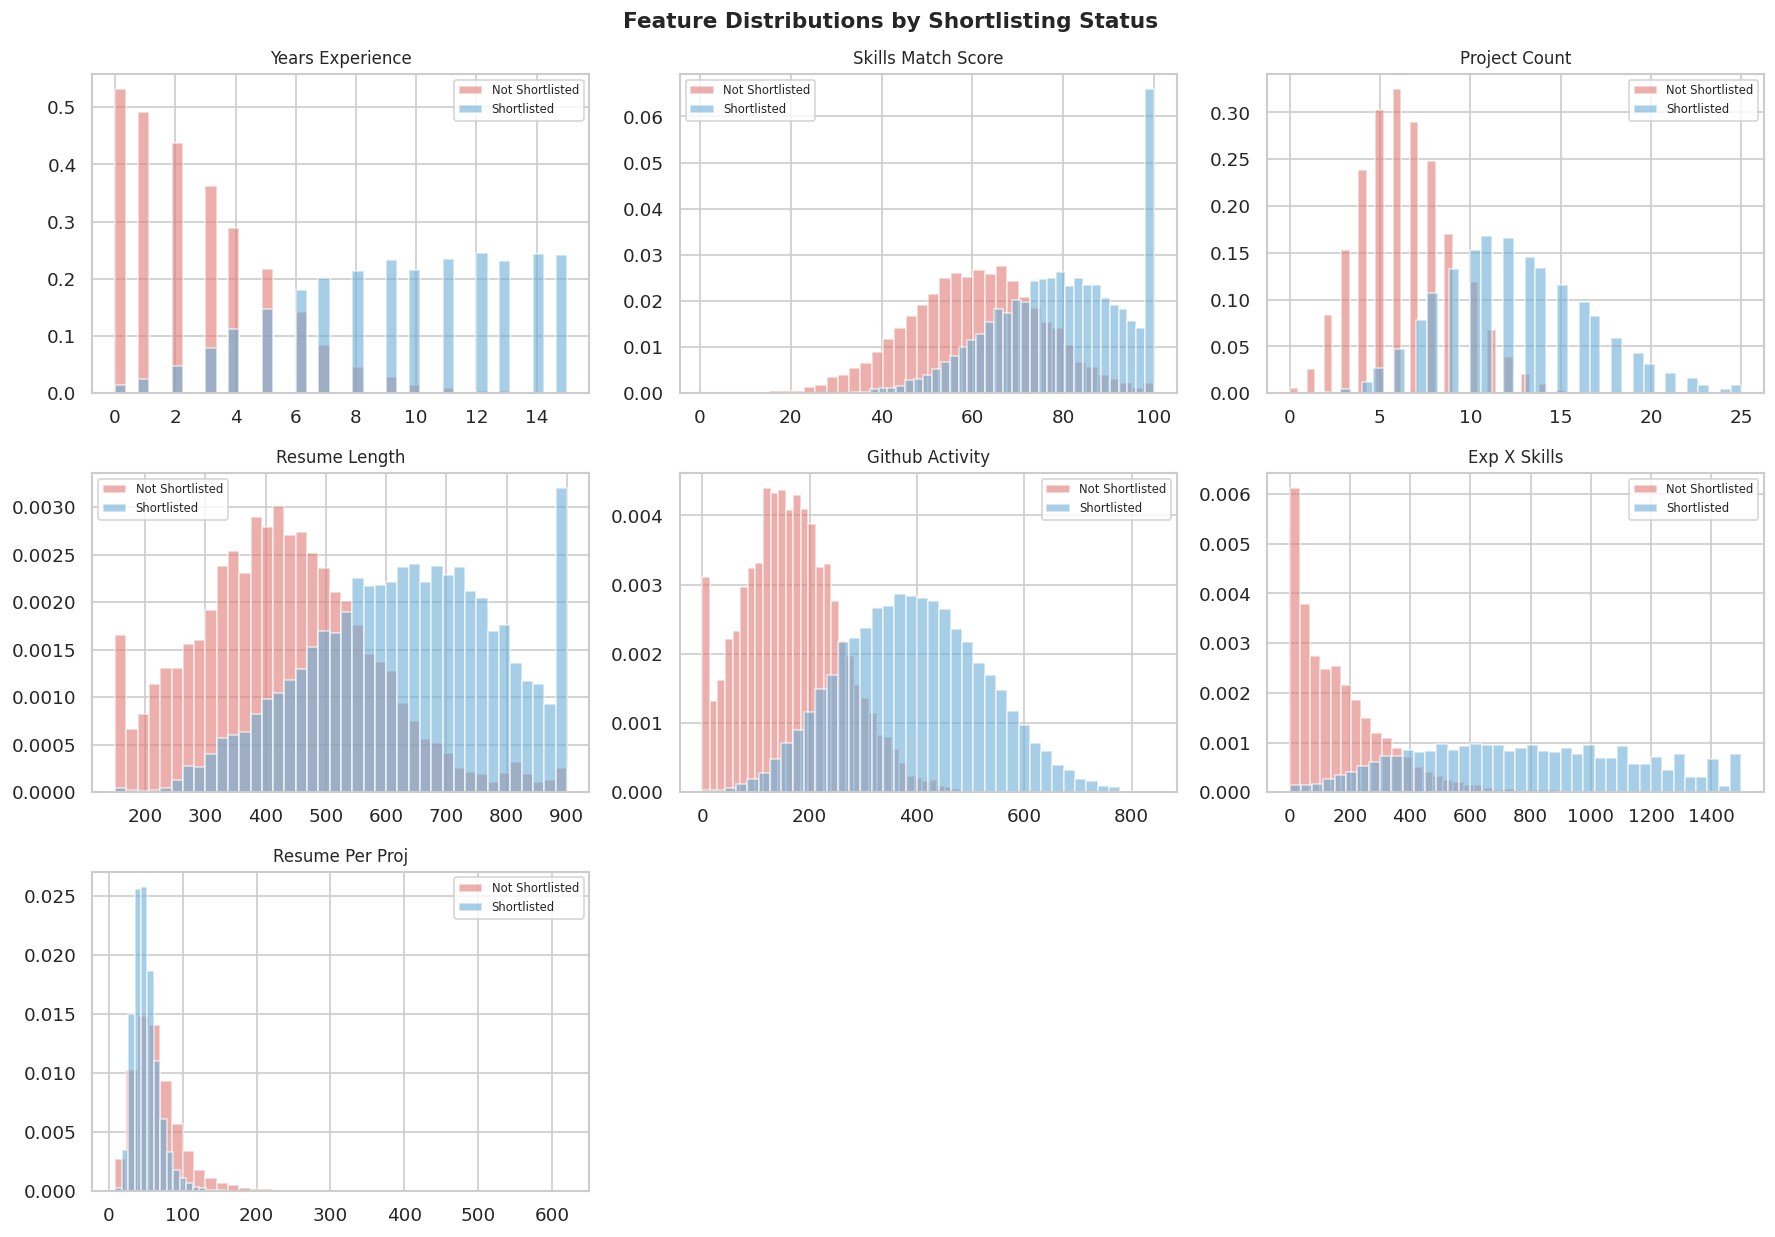

In [52]:
num_cols = ['years_experience', 'skills_match_score', 'project_count',
            'resume_length', 'github_activity',
            'exp_x_skills', 'resume_per_proj']

n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in zip([0, 1], ['#E07B74', '#6BAED6']):
        axes[i].hist(df_clean[df_clean['shortlisted'] == label][col],
                     bins=40, alpha=0.6, color=color,
                     label='Shortlisted' if label == 1 else 'Not Shortlisted',
                     density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Shortlisting Status', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

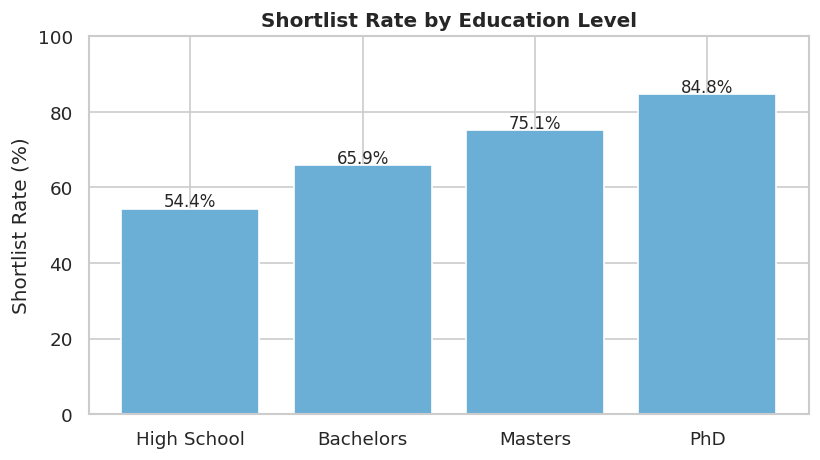

In [53]:
hire_by_edu = df_clean.groupby('education_level')['shortlisted'].mean() * 100
labels = [edu_order[int(i)] for i in hire_by_edu.index]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, hire_by_edu.values, color='#6BAED6', edgecolor='white')
for bar, val in zip(bars, hire_by_edu.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_title('Shortlist Rate by Education Level', fontweight='bold')
ax.set_ylabel('Shortlist Rate (%)')
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Feature Engineering and Train/Test Split

In [54]:
X = df_clean.drop(columns=['shortlisted'])
y = df_clean['shortlisted']

print('Feature matrix shape:', X.shape)
print('Target vector shape: ', y.shape)
print('Features:', X.columns.tolist())

Feature matrix shape: (30000, 8)
Target vector shape:  (30000,)
Features: ['years_experience', 'skills_match_score', 'education_level', 'project_count', 'resume_length', 'github_activity', 'exp_x_skills', 'resume_per_proj']


In [55]:
# Train / Test split (80 / 20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set          : {X_train.shape[0]:,} samples')
print(f'Test set              : {X_test.shape[0]:,} samples')
print(f'Train shortlisted %   : {y_train.mean()*100:.2f}%')
print(f'Test  shortlisted %   : {y_test.mean()*100:.2f}%')

Training set          : 24,000 samples
Test set              : 6,000 samples
Train shortlisted %   : 69.89%
Test  shortlisted %   : 69.88%


In [56]:
# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling complete. Mean (first 3 features):', X_train_sc.mean(axis=0)[:3].round(4))

Scaling complete. Mean (first 3 features): [-0.  0. -0.]


## 6. Model Training

In [57]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


In [58]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print('Random Forest trained.')

Random Forest trained.


In [59]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=y_train.value_counts()[0] / y_train.value_counts()[1],
    random_state=RANDOM_STATE,
    eval_metric='logloss',
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print('XGBoost trained.')

XGBoost trained.


## 7. Model Evaluation

In [60]:
def evaluate_model(name, model, X_eval, y_eval, scaled=False):
    y_pred  = model.predict(X_eval)
    y_prob  = model.predict_proba(X_eval)[:, 1]
    return {
        'Model' : name,
        'Accuracy' : accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred),
        'Recall' : recall_score(y_eval, y_pred),
        'F1-Score' : f1_score(y_eval, y_pred),
        'ROC-AUC' : roc_auc_score(y_eval, y_prob),
        '_y_pred' : y_pred,
        '_y_prob' : y_prob,
    }

results = [
    evaluate_model('Logistic Regression', lr,  X_test_sc, y_test),
    evaluate_model('Random Forest', rf, X_test, y_test),
    evaluate_model('XGBoost', xgb, X_test, y_test),  # XGBoost uses unscaled data
]

metrics_df = pd.DataFrame(results).drop(columns=['_y_pred', '_y_prob']).set_index('Model')
print('=== Test-Set Metrics ===')

styled_df = metrics_df.style.format('{:.4f}').highlight_max(axis=0, props='background-color: #d5f5d5; color: black;')
display(styled_df)

=== Test-Set Metrics ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8920,0.9577,0.8846,0.9197,0.9650
Random Forest,0.9025,0.9347,0.9251,0.9299,0.9641
XGBoost,0.8927,0.9478,0.8958,0.9210,0.9654


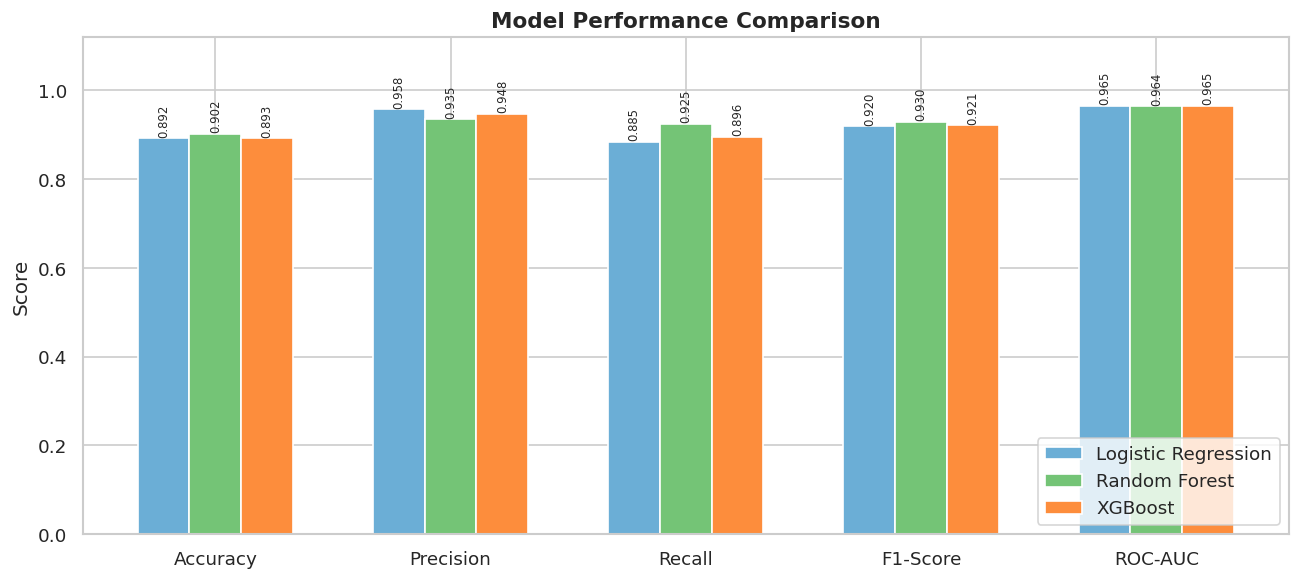

In [61]:
fig, ax = plt.subplots(figsize=(11, 5))
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(metric_cols))
colors = ['#6BAED6', '#74C476', '#FD8D3C']
width = 0.22

for i, (row, color) in enumerate(zip(results, colors)):
    vals = [row[m] for m in metric_cols]
    bars = ax.bar(x + (i - 1) * width, vals, width,
                  label=row['Model'], color=color, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003, f'{v:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

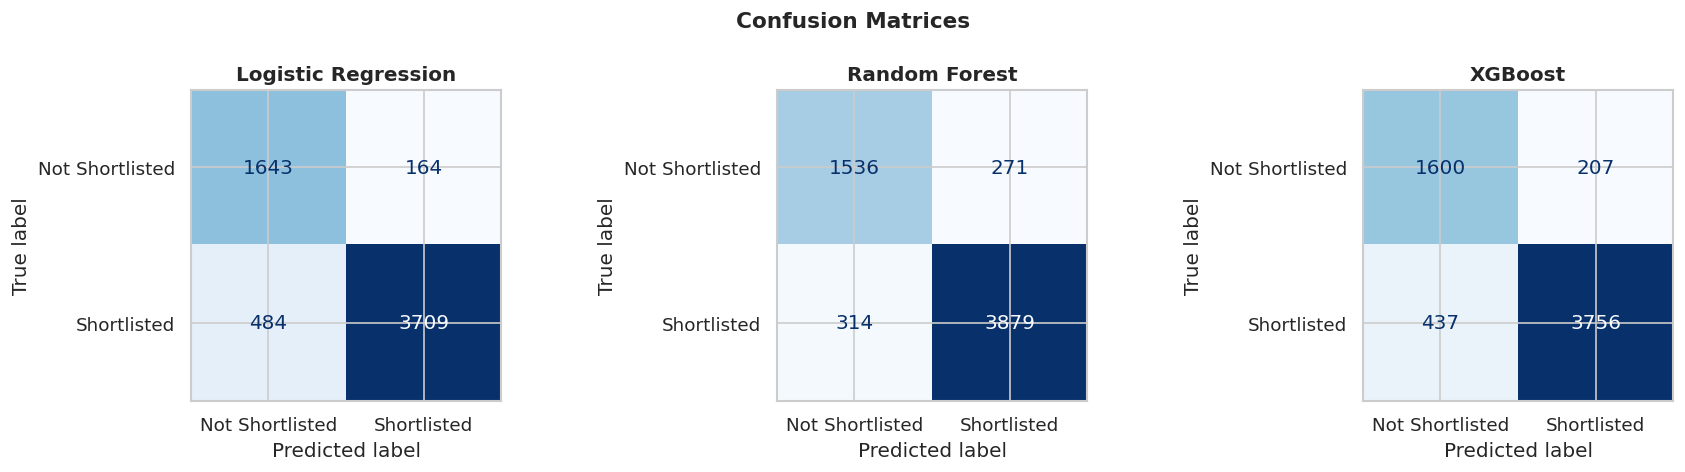

In [62]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, row in zip(axes, results):
    cm = confusion_matrix(y_test, row['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Shortlisted', 'Shortlisted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(row['Model'], fontweight='bold')

fig.suptitle('Confusion Matrices', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

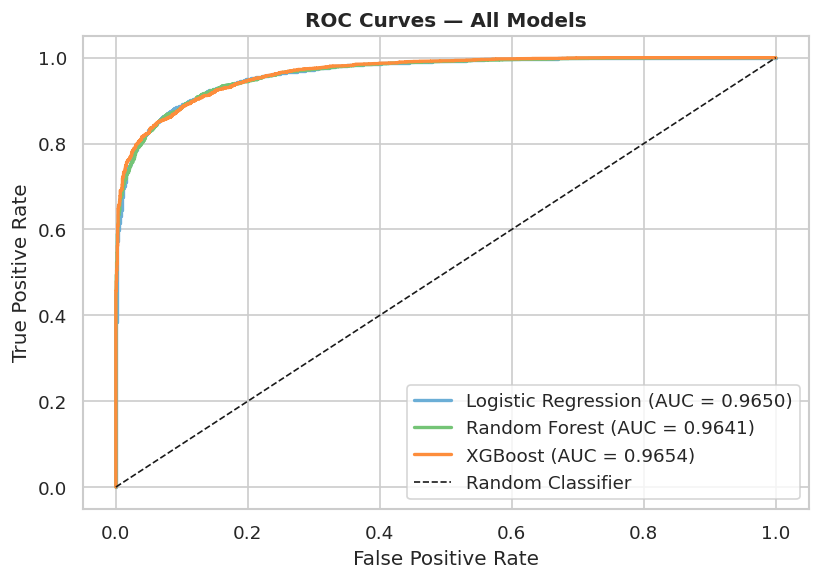

In [63]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#6BAED6', '#74C476', '#FD8D3C']

for row, color in zip(results, colors):
    fpr, tpr, _ = roc_curve(y_test, row['_y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{row['Model']} (AUC = {row['ROC-AUC']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [64]:
for row in results:
    print(f"\n{'='*50}")
    print(f"  {row['Model']}")
    print(f"{'='*50}")
    print(classification_report(y_test, row['_y_pred'],
                                target_names=['Not Shortlisted', 'Shortlisted']))


  Logistic Regression
                 precision    recall  f1-score   support

Not Shortlisted       0.77      0.91      0.84      1807
    Shortlisted       0.96      0.88      0.92      4193

       accuracy                           0.89      6000
      macro avg       0.87      0.90      0.88      6000
   weighted avg       0.90      0.89      0.89      6000


  Random Forest
                 precision    recall  f1-score   support

Not Shortlisted       0.83      0.85      0.84      1807
    Shortlisted       0.93      0.93      0.93      4193

       accuracy                           0.90      6000
      macro avg       0.88      0.89      0.88      6000
   weighted avg       0.90      0.90      0.90      6000


  XGBoost
                 precision    recall  f1-score   support

Not Shortlisted       0.79      0.89      0.83      1807
    Shortlisted       0.95      0.90      0.92      4193

       accuracy                           0.89      6000
      macro avg       0.87   

## 8. Cross Validation

In [65]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = [
    ('Logistic Regression', lr,  X_train_sc, y_train),
    ('Random Forest',       rf,  X_train,    y_train),
    ('XGBoost',             xgb, X_train,    y_train),  # unscaled — fixed
]

cv_results = {}
for name, model, Xtr, ytr in cv_models:
    scores = cross_val_score(model, Xtr, ytr, cv=cv,
                             scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:25s} | F1 per fold: {scores.round(4)} '
          f'| Mean: {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression       | F1 per fold: [0.919  0.9213 0.9246 0.9226 0.9239] | Mean: 0.9223 ± 0.0020
Random Forest             | F1 per fold: [0.9318 0.9258 0.9344 0.9302 0.9323] | Mean: 0.9309 ± 0.0029
XGBoost                   | F1 per fold: [0.9261 0.9247 0.9284 0.9257 0.9262] | Mean: 0.9262 ± 0.0012


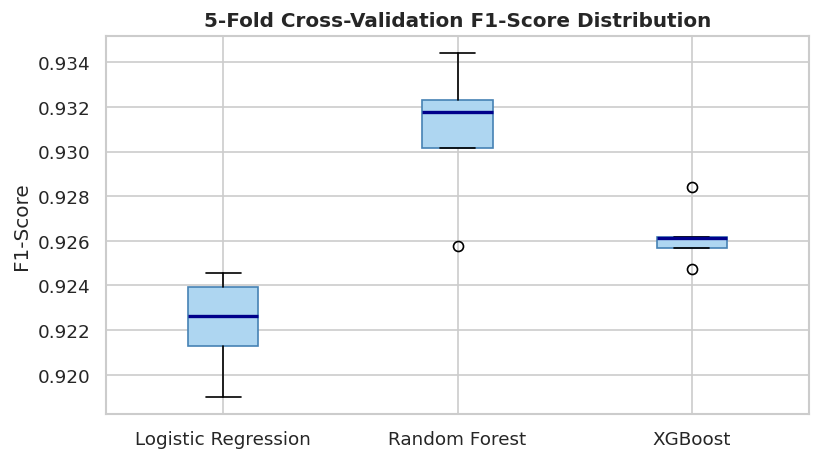

In [66]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
           boxprops=dict(facecolor='#AED6F1', color='steelblue'),
           medianprops=dict(color='darkblue', linewidth=2))
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold Cross-Validation F1-Score Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Feature Importance (Random Forest & XGBoost)

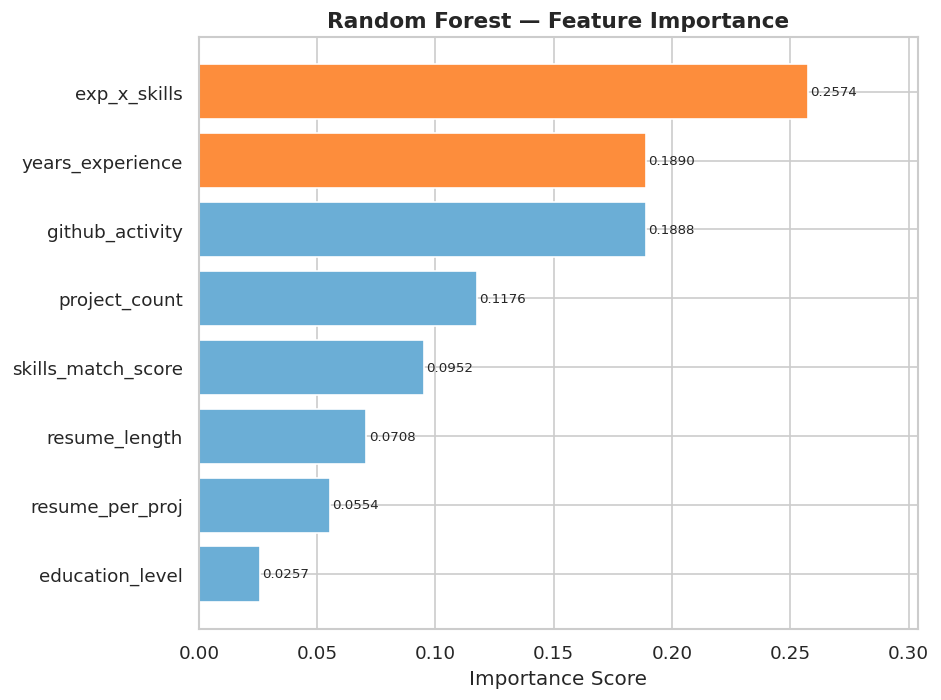


Top 3 most influential features:
  exp_x_skills: 0.2574
  years_experience: 0.1890
  github_activity: 0.1888


In [67]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_fi = ['#FD8D3C' if v >= importances.quantile(0.75) else '#6BAED6'
             for v in importances.values]
bars = ax.barh(importances.index, importances.values,
               color=colors_fi, edgecolor='white')
for bar, v in zip(bars, importances.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest — Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()

print('\nTop 3 most influential features:')
for feat, val in importances.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {val:.4f}')

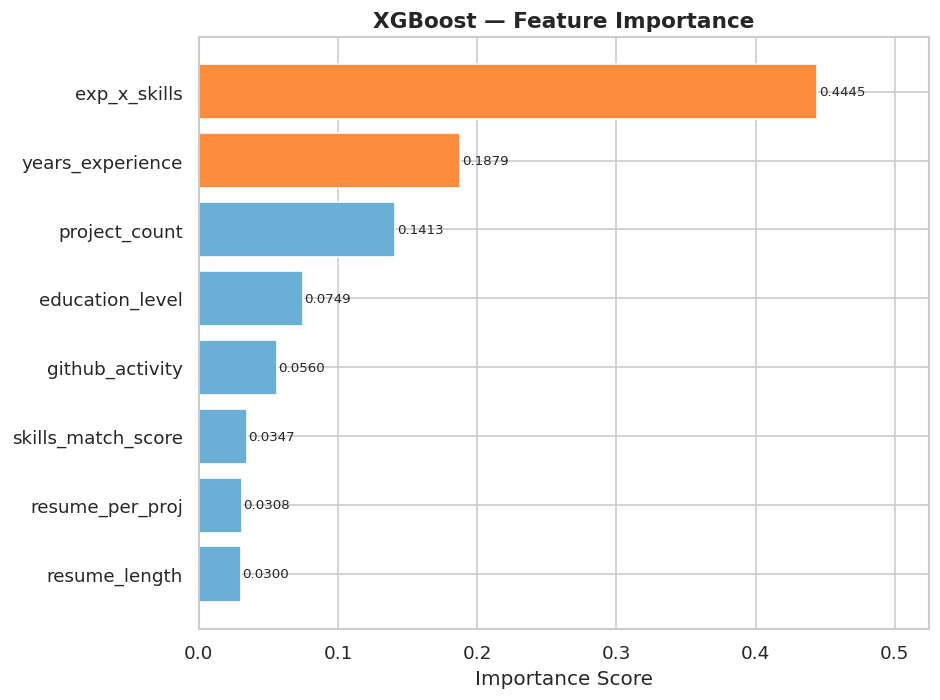


Top 3 most influential features:
  exp_x_skills: 0.4445
  years_experience: 0.1879
  project_count: 0.1413


In [68]:
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
importances_xgb = importances_xgb.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_xgb = ['#FD8D3C' if v >= importances_xgb.quantile(0.75) else '#6BAED6'
               for v in importances_xgb.values]
bars = ax.barh(importances_xgb.index, importances_xgb.values,
               color=colors_xgb, edgecolor='white')
for bar, v in zip(bars, importances_xgb.values):
    ax.text(v + 0.001, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center', fontsize=8)
ax.set_xlabel('Importance Score')
ax.set_title('XGBoost — Feature Importance', fontweight='bold', fontsize=13)
ax.set_xlim(0, importances_xgb.max() * 1.18)
plt.tight_layout()
plt.show()

print('\nTop 3 most influential features:')
for feat, val in importances_xgb.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {val:.4f}')

## 10. Coefficient Analysis (Logistic Regression)

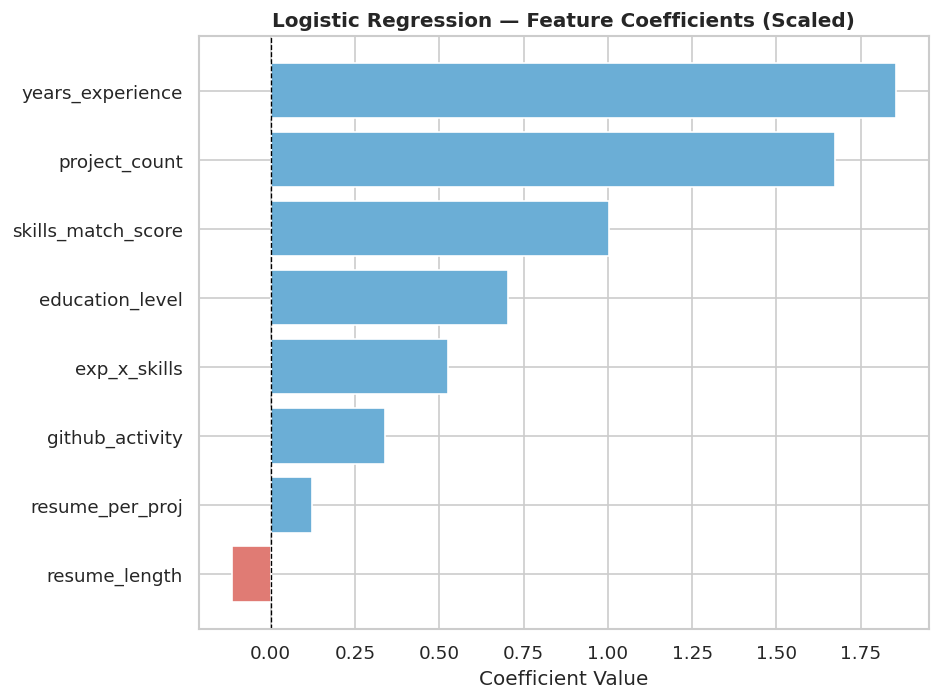

In [69]:
coef = pd.Series(lr.coef_[0], index=X.columns)
coef_sorted = coef.sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors_coef = ['#E07B74' if v < 0 else '#6BAED6' for v in coef_sorted.values]
ax.barh(coef_sorted.index, coef_sorted.values,
        color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient Value')
ax.set_title('Logistic Regression — Feature Coefficients (Scaled)', fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Save Model

In [70]:
# os.makedirs('models', exist_ok=True)

# joblib.dump(lr,     'models/logistic_regression.pkl')
# joblib.dump(rf,     'models/random_forest.pkl')
# joblib.dump(xgb,    'models/xgboost.pkl')
# joblib.dump(scaler, 'models/scaler.pkl')
# joblib.dump(oe,     'models/ordinal_encoder.pkl')

# print('All models and preprocessing artifacts saved to /models/')

# # Verify reload
# rf_loaded = joblib.load('models/random_forest.pkl')
# print(f'Reload check — RF accuracy: {accuracy_score(y_test, rf_loaded.predict(X_test)):.4f}')

# # Save best model to Google Drive
# best = max(results, key=lambda r: r['F1-Score'])
# best_model_map = {
#     'Logistic Regression': lr,
#     'Random Forest':       rf,
#     'XGBoost':             xgb,
# }
# best_model = best_model_map[best['Model']]
# best_path  = f'models/best_model_{best["Model"].replace(" ", "_").lower()}.pkl'
# joblib.dump(best_model, best_path)
# print(f'\nBest model: {best["Model"]} (F1={best["F1-Score"]:.4f}) → saved to {best_path}')

# # Mount Google Drive and copy
# from google.colab import drive
# drive.mount('/content/drive', force_remount=False)

# drive_dir = '/content/drive/MyDrive/ML_Models/Kelompok10'
# os.makedirs(drive_dir, exist_ok=True)

# import shutil
# dest = shutil.copy(best_path, drive_dir)
# print(f'Best model uploaded to Google Drive: {dest}')

All models and preprocessing artifacts saved to /models/
Reload check — RF accuracy: 0.9025

Best model: Random Forest (F1=0.9299) → saved to models/best_model_random_forest.pkl
Mounted at /content/drive
Best model uploaded to Google Drive: /content/drive/MyDrive/ML_Models/Kelompok10/best_model_random_forest.pkl
